In [2]:
#------------------------------
# IMPORTAÇÃO DAS BIBLIOTECAS
#------------------------------
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [13]:
#------------------------------
# CARREGANDO OS DADOS
#------------------------------
df_query1 = pd.read_csv('C:\\Users\\Usuário\\Downloads\\SCTEC\\AULAS SCTEC\\Visualiza-o--Dados-BI-Semana_9\\projeto-rh-sql-python\\data\\processed_data\\query_01.csv', sep=',', encoding='utf-8')


In [17]:
#------------------------------
# CONHECENDO OS DADOS
#------------------------------

df_query1.head(10)


,EMPLOYEE_ID,FIRST_NAME,LAST_NAME,FULL_NAME,SALARY,JOB_TITLE,DEPARTMENT_ID,DEPARTMENT_NAME,MIN_SALARY,MAX_SALARY
0,205,Shelley,Higgins,Shelley Higgins,12008,Accounting Manager,110,Accounting,8200,16000
1,206,William,Gietz,William Gietz,8300,Public Accountant,110,Accounting,4200,9000
2,200,Jennifer,Whalen,Jennifer Whalen,4400,Administration Assistant,10,Administration,3000,6000
3,100,Steven,King,Steven King,24000,President,90,Executive,20080,40000
4,101,Neena,Yang,Neena Yang,17000,Administration Vice President,90,Executive,15000,30000
5,102,Lex,Garcia,Lex Garcia,17000,Administration Vice President,90,Executive,15000,30000
6,108,Nancy,Gruenberg,Nancy Gruenberg,12008,Finance Manager,100,Finance,8200,16000
7,109,Daniel,Faviet,Daniel Faviet,9000,Accountant,100,Finance,4200,9000
8,110,John,Chen,John Chen,8200,Accountant,100,Finance,4200,9000
9,112,Jose Manuel,Urman,Jose Manuel Urman,7800,Accountant,100,Finance,4200,9000


In [18]:
df_query1.info()

<class 'pandas.DataFrame'>
RangeIndex: 106 entries, 0 to 105
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   EMPLOYEE_ID      106 non-null    int64
 1   FIRST_NAME       106 non-null    str  
 2   LAST_NAME        106 non-null    str  
 3   FULL_NAME        106 non-null    str  
 4   SALARY           106 non-null    int64
 5   JOB_TITLE        106 non-null    str  
 6   DEPARTMENT_ID    106 non-null    int64
 7   DEPARTMENT_NAME  106 non-null    str  
 8   MIN_SALARY       106 non-null    int64
 9   MAX_SALARY       106 non-null    int64
dtypes: int64(5), str(5)
memory usage: 8.4 KB


O conjunto de dados contém 106 funcionários distribuídos em diferentes departamentos e cargos.

Foram importadas 10 colunas, contendo informações cadastrais e salariais.

Não foram encontrados valores nulos nas colunas analisadas, indicando boa qualidade dos dados para a etapa exploratória.

In [ ]:
#--------------------------------------
# CONHECENDO AS ESTATÍSTICAS DOS DADOS
#--------------------------------------

df_query1.describe()

,EMPLOYEE_ID,SALARY,DEPARTMENT_ID,MIN_SALARY,MAX_SALARY
count,106.000000,106.000000,106.000000,106.000000,106.000000
mean,152.764151,6456.754717,63.207547,4701.320755,9708.792453
std,31.083161,3927.798234,20.910110,3037.952780,5756.754097
min,100.000000,2100.000000,10.000000,2008.000000,5000.000000
25%,126.250000,3100.000000,50.000000,2500.000000,5500.000000
50%,152.500000,6150.000000,50.000000,4100.000000,9000.000000
75%,179.750000,8950.000000,80.000000,6000.000000,12008.000000
max,206.000000,24000.000000,110.000000,20080.000000,40000.000000


In [ ]:
#--------------------------------------------------
# CONHECENDO AS ESTATÍSTICAS DESCRITIVAS DA TABELA
#--------------------------------------------------

print(f"Média salarial: {df_query1['SALARY'].mean():.2f}")

print(f"Mediana salarial: {df_query1['SALARY'].median():.2f}")

print(f"Menor salário: {df_query1['SALARY'].min()}")

print(f"Maior salário: {df_query1['SALARY'].max()}")

Média salarial: 6456.75
Mediana salarial: 6150.00
Menor salário: 2100
Maior salário: 24000


In [ ]:
#-------------------------------------------
# VERIFICANDO A EXISTÊNCIA DE VALORES NULOS
#-------------------------------------------

df_query1.isnull().sum()

EMPLOYEE_ID        0
FIRST_NAME         0
LAST_NAME          0
FULL_NAME          0
SALARY             0
JOB_TITLE          0
DEPARTMENT_ID      0
DEPARTMENT_NAME    0
MIN_SALARY         0
MAX_SALARY         0
dtype: int64

Não há valores nulos na nossa tabela

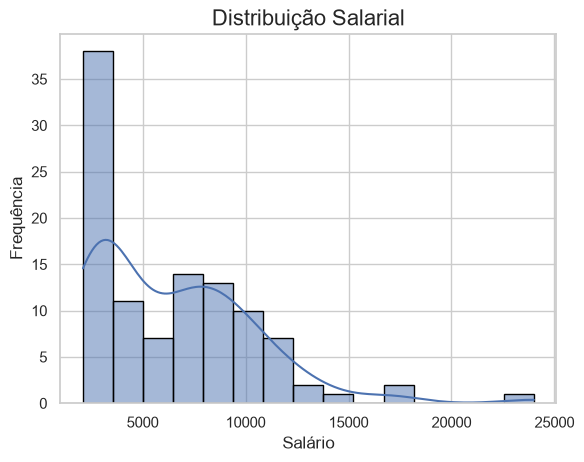

In [33]:
#-------------------------------------
# ANÁLISE GRÁFICA DOS DADOS DA TABELA
#-------------------------------------
# HISTOGRAMA DA DISTRIBUIÇÃO SALARIAL
#-------------------------------------

sns.set_theme(style="whitegrid")
sns.histplot(df_query1['SALARY'], 
             bins=15, 
             kde=True,
             edgecolor='black'
             )
plt.title('Distribuição Salarial', fontsize=16)
plt.xlabel('Salário', fontsize=12)
plt.ylabel('Frequência', fontsize=12)
plt.show()



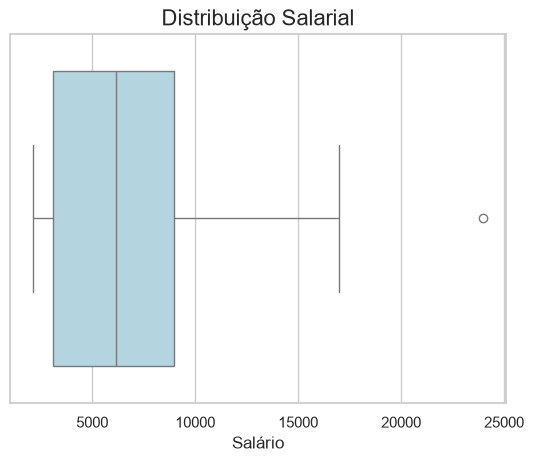

In [36]:
#-------------------------------------
# ANÁLISE GRÁFICA DOS DADOS DA TABELA
#-------------------------------------
# BOXPLOT DA DISTRIBUIÇÃO SALARIAL
#-------------------------------------
sns.set_theme(style="whitegrid")
sns.boxplot(x=df_query1['SALARY'],
            color='lightblue')
plt.title('Distribuição Salarial', fontsize=16)
plt.xlabel('Salário', fontsize=12)

plt.show()


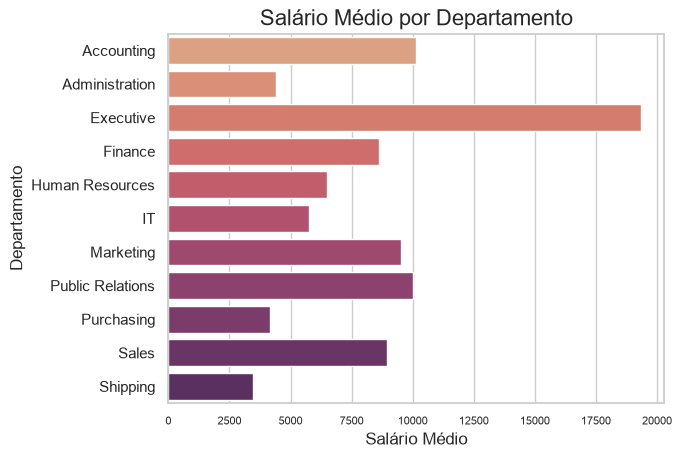

In [48]:
#-------------------------------------
# ANÁLISE GRÁFICA DOS DADOS DA TABELA
#-------------------------------------
# SALÁRIO MÉDIO POR DEPARTAMENTO
#-------------------------------------
sns.set_theme(style="whitegrid")
sns.barplot(data=df_query1.groupby('DEPARTMENT_NAME')['SALARY'].mean().reset_index(),
            x='SALARY',
            y='DEPARTMENT_NAME',
            hue='DEPARTMENT_NAME',
            palette='flare',
            legend=False)
plt.xticks(fontsize=8)
plt.title('Salário Médio por Departamento', fontsize=16)
plt.xlabel('Salário Médio', fontsize=12)
plt.ylabel('Departamento', fontsize=12)
plt.show()

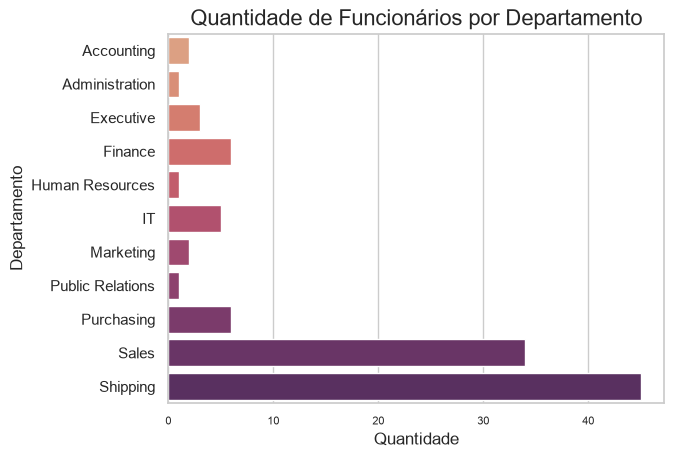

In [54]:
#-------------------------------------
# ANÁLISE GRÁFICA DOS DADOS DA TABELA
#-------------------------------------
# QUANTIDADE DE FUNCIONÁRIOS POR DEPARTAMENTO
#-------------------------------------
sns.set_theme(style="whitegrid")
sns.barplot(data=df_query1.groupby('DEPARTMENT_NAME').size().reset_index(name='COUNT'),
            x='COUNT',
            y='DEPARTMENT_NAME',
            hue='DEPARTMENT_NAME',
            palette='flare',
            legend=False)
plt.xticks(fontsize=8)
plt.title('Quantidade de Funcionários por Departamento', fontsize=16)
plt.xlabel('Quantidade', fontsize=12)
plt.ylabel('Departamento', fontsize=12)
plt.show()